# NLP Assignment: Text Classification for Cybersecurity Threats

**Link GitHub:** *https://github.com/1337strike/NLP-Text-Classification*

### Part 0: Article & Problem Statement
* **Theme:** "The Rise of Smishing: How Text-Based Social Engineering Leads to Institutional Data Breaches."
* **Problem Formulation:** To mitigate the risk of unauthorized access and data breaches, organizations must automatically filter malicious communications. We will develop a supervised text classification solution to categorize incoming text messages as either legitimate ("Ham") or malicious ("Spam/Phishing").

### Part 1: Data Collection
1. **Dataset Description:**
* **Source:** The UCI Machine Learning Repository (SMS Spam Collection Dataset).
* **Sample Size:** 5,572 text messages.
* **Features:** Two primary columns: `label` (classification of the message as 'ham' or 'spam') and `message` (the raw text content of the SMS).

In [34]:
# Import necessary libraries
import pandas as pd
import urllib.request
import zipfile
import os

# Download and extract the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
file_name = "smsspamcollection.zip"
urllib.request.urlretrieve(url, file_name)

with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall("sms_data")

# Load the dataset using Pandas
df = pd.read_csv('sms_data/SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])

# Display a summary and the first few rows
print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['label'].value_counts())
display(df.head())

Dataset Shape: (5572, 2)

Class Distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Part 2: Text Preprocessing
**Preprocessing Steps Applied:**
1. **Lowercasing:** Standardizes all text to lowercase.
2. **Punctuation Removal:** Strips special characters using regular expressions.
3. **Tokenization:** Splits the text into individual words.
4. **Stopword Removal:** Filters out common, uninformative words.
5. **Stemming:** Reduces words to their root form.

In [35]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to resolve LookupError

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    # Nah, baris di bawah ini sekarang udah sejajar!
    processed_tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(processed_tokens)

# Apply preprocessing
df['cleaned_message'] = df['message'].apply(preprocess_text)

# Show examples before and after
print("Original Text:\n", df['message'].iloc[2])
print("\nPreprocessed Text:\n", df['cleaned_message'].iloc[2])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Original Text:
 Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Preprocessed Text:
 free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over


### Part 3: Feature Engineering
1. **TF-IDF:** Evaluates how important a word is to a document relative to a corpus. It increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus.
2. **Word2Vec:** A predictive neural network model that learns word associations from a large corpus, creating dense vector representations (embeddings) for words.

In [36]:
!pip install gensim
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

# 1. TF-IDF Representation
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df['cleaned_message']).toarray()
print("TF-IDF Matrix Shape:", X_tfidf.shape)

# 2. Word2Vec Representation
sentences = [word_tokenize(msg) for msg in df['cleaned_message']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# Check if the word exists in vocabulary to avoid KeyError
word = 'secur'
if word in w2v_model.wv:
    print(f"\nWord2Vec embedding for '{word}':\n", w2v_model.wv[word][:5], "...")
else:
    print(f"\nWord '{word}' not found in Word2Vec vocabulary.")

TF-IDF Matrix Shape: (5572, 1000)

Word2Vec embedding for 'secur':
 [-0.00066477  0.01399749 -0.00029183 -0.00122865  0.0114254 ] ...


### Part 4: Exploratory Data Analysis and Visualization

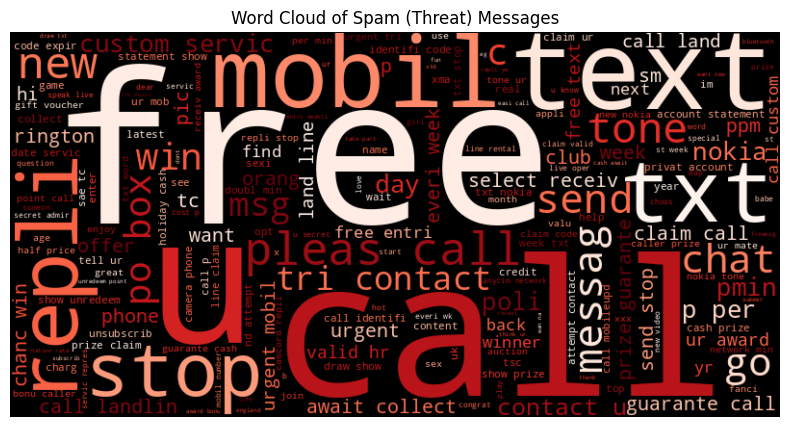

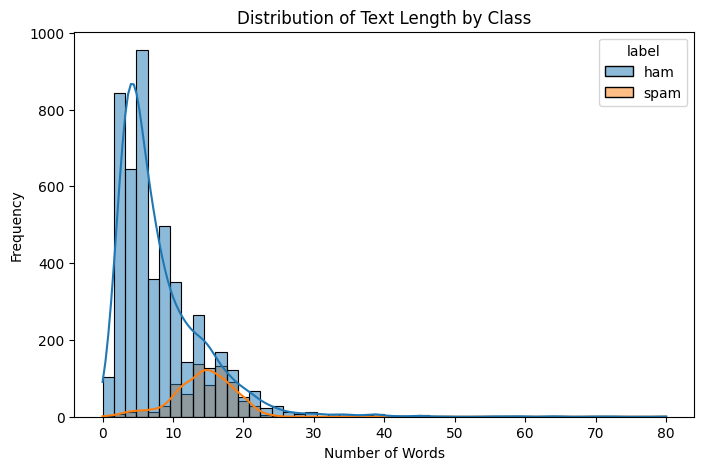

/tmp/ipykernel_5789/3238419529.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=common_words, palette='viridis')


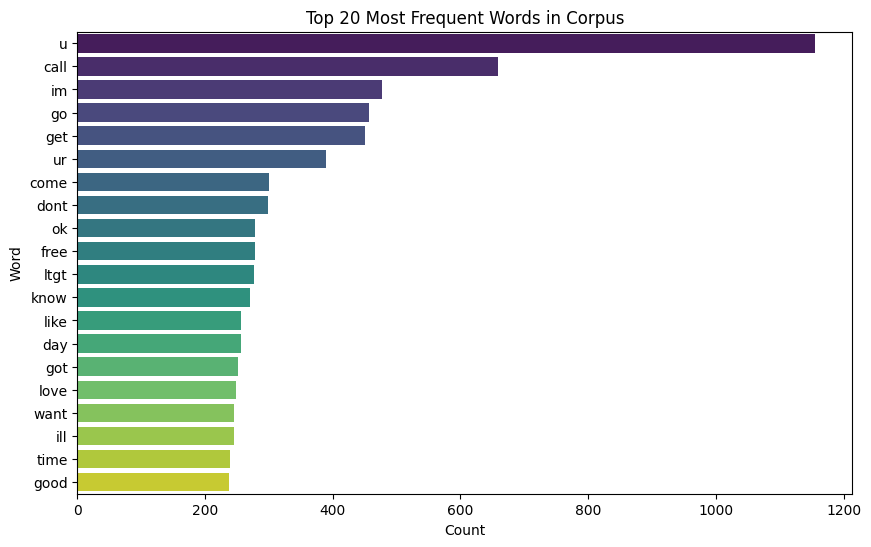

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# 1. Word Cloud for Spam Messages
spam_words = ' '.join(list(df[df['label'] == 'spam']['cleaned_message']))
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(spam_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of Spam (Threat) Messages')
plt.axis('off')
plt.show()

# 2. Distribution of Text Length
df['msg_length'] = df['cleaned_message'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='msg_length', hue='label', bins=50, kde=True)
plt.title('Distribution of Text Length by Class')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# 3. Bar Plot of Top Words
all_words = ' '.join(df['cleaned_message']).split()
word_counts = Counter(all_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Word', data=common_words, palette='viridis')
plt.title('Top 20 Most Frequent Words in Corpus')
plt.show()

### Part 5: Text Classification

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Encode labels: Spam = 1, Ham = 0
y = df['label'].map({'spam': 1, 'ham': 0})

# Split data into training and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Train a Naive Bayes Classifier
classifier = MultinomialNB()
classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = classifier.predict(X_test)

# Report results
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

Classification Report:

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.86      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Accuracy: 0.9794
Precision: 0.9846
Recall: 0.8591
F1 Score: 0.9176


### Part 6: Theory Questions

**1. Difference between Text Classification and Text Clustering:**
Text classification is a *supervised* machine learning approach where documents are assigned to pre-defined target categories using a model trained on a labeled dataset. In contrast, text clustering is an *unsupervised* learning approach that groups documents based solely on their internal semantic or lexical similarities, without relying on pre-existing labels.
* **Reference:** Aggarwal, C. C., & Zhai, C. (2012). *Mining Text Data*. Springer. Chapter 6: A Survey of Text Classification Algorithms (Page 163, Paragraph 1). "The problem of classification is that of assigning a text document to one or more of a set of pre-defined categories..." Contrastingly, Chapter 4 (Page 77, Paragraph 1) states that text clustering groups items based on structural similarity without labeled classes.

**2. When to Apply Text Clustering:**
Text clustering is most useful when dealing with vast, unexplored textual corpora where manual labeling is impossible or prohibitively expensive. It is utilized heavily in exploratory data analysis to discover hidden structures and topic modeling.
* **Examples:** Automatically grouping customer feedback into specific unprompted themes (e.g., identifying a cluster of complaints about "shipping delays"), or routing daily news articles into discrete structural clusters without prior human tagging.
* **Reference:** Aggarwal, C. C., & Zhai, C. (2012). *Mining Text Data*. Springer. Chapter 4: A Survey of Text Clustering Algorithms (Page 77, Paragraph 1). "Text clustering algorithms are widely used for exploratory data analysis... organizing large document collections, and topic extraction."

**3. Determining Optimal Clusters in K-Means:**
When using K-Means, two heavily utilized methods to deduce the optimal $K$ are:
* **The Elbow Method:** This involves plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters. The optimal $K$ is found at the "elbow" point of the graph, where the rate of decline in WCSS abruptly slows down.
* **The Silhouette Coefficient:** This metric assesses how similar an object is to its own cluster compared to other clusters. The optimal number of clusters maximizes the average Silhouette score, indicating tight, well-separated clusters.
* **Reference (Silhouette Method):** Rousseeuw, P. J. (1987). "Silhouettes: a graphical aid to the interpretation and validation of cluster analysis." *Journal of Computational and Applied Mathematics*, 20, 53-65. (Page 54, Paragraph 2).
* **Reference (Elbow Method):** Bholowalia, P., & Kumar, A. (2014). "EBK-Means: A Clustering Technique based on Elbow Method and K-Means in WSN." *International Journal of Computer Applications*, 105(9). (Page 17, Section 3.1).